# 🔬 Hands-on Lab: SHAP & LIME for Explainable AI
**Course:** Explainable Artificial Intelligence (23AM501)  
**Department:** CSE (AI & ML) — SKCET, Coimbatore  

---
### Lab Objectives
By the end of this lab, you will be able to:
1. Train a Random Forest classifier on the **Diabetes (Pima Indians) dataset**
2. Generate and interpret **SHAP** (SHapley Additive exPlanations) values
3. Generate and interpret **LIME** (Local Interpretable Model-agnostic Explanations)
4. Compare both methods and understand when to use each

**Estimated time:** 90 minutes  
**Run each cell in order. Do not skip cells.**

---


## Step 1 — Install Required Libraries
> Run this cell first. It may take 1–2 minutes.

In [1]:
!pip install shap lime scikit-learn pandas matplotlib seaborn --quiet
print("✅ All libraries installed successfully!")


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

✅ All libraries installed successfully!


## Step 2 — Import Libraries

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import lime
import lime.lime_tabular
import lime.discretize
import scipy.stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report

# For reproducibility
np.random.seed(42)
shap.initjs()

# ── LIME compatibility fix ──────────────────────────────────────────────────────
# Some scipy/lime version combinations produce NaN scale values in truncnorm.rvs.
# This patch gracefully falls back to the bin mean when that happens.
def _safe_undiscretize(self, feature, values):
    mins  = np.array(self.mins[feature])[values]
    maxs  = np.array(self.maxs[feature])[values]
    means = np.array(self.means[feature])[values]
    stds  = np.maximum(np.array(self.stds[feature])[values], 1e-10)
    minz  = (mins - means) / stds
    maxz  = (maxs - means) / stds
    min_max_unequal = (minz != maxz)
    ret   = minz.copy().astype(float)
    if np.any(min_max_unequal):
        idx = np.where(min_max_unequal)
        a, b = minz[idx], maxz[idx]
        loc_v, sc = means[idx], stds[idx]
        try:
            ret[idx] = scipy.stats.truncnorm.rvs(
                a, b, loc=loc_v, scale=sc, random_state=self.random_state)
        except Exception:
            ret[idx] = loc_v   # fall back to bin mean
    return ret

lime.discretize.BaseDiscretizer.get_undiscretize_values = _safe_undiscretize

# ── Shared Initialization & Verification Helper ─────────────────────────────────
def ensure_ready(stage='all'):
    """
    Shared initialization and state verification function.
    Ensures data loading, pipeline fitting, and explainer initialization
    if cells are run out of sequence.
    """
    global df, X_train, X_test, y_train, y_test, pipeline, model, imputer
    global feature_names, explainer, shap_values, lime_explainer

    if 'model' not in globals() or 'X_test' not in globals():
        print("⚙️ Initializing data and fitting leakage-free pipeline...")
        local_path = os.path.join('data', 'pima-indians-diabetes.data.csv')
        url = ("https://raw.githubusercontent.com/jbrownlee/Datasets/master/"
               "pima-indians-diabetes.data.csv")
        col_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                     'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

        if os.path.exists(local_path):
            df = pd.read_csv(local_path, names=col_names)
        else:
            df = pd.read_csv(url, names=col_names)

        zero_replace_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
        for col in zero_replace_cols:
            df[col] = df[col].replace(0, np.nan)

        feature_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                         'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
        X = df[feature_names].values
        y = df['Outcome'].values

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y)

        pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
        ])
        pipeline.fit(X_train, y_train)

        imputer = pipeline.named_steps['imputer']
        model = pipeline.named_steps['classifier']
        X_train = imputer.transform(X_train)
        X_test = imputer.transform(X_test)
        print(f"  Model & Imputer ready. Accuracy: {model.score(X_test, y_test):.3f}")

    if stage in ('all', 'shap') and ('shap_values' not in globals() or 'explainer' not in globals()):
        print("⚙️ Initializing SHAP TreeExplainer...")
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)
        print("  SHAP values ready.")

    if stage in ('all', 'lime') and 'lime_explainer' not in globals():
        print("⚙️ Initializing LIME TabularExplainer...")
        lime_explainer = lime.lime_tabular.LimeTabularExplainer(
            training_data=X_train,
            feature_names=feature_names,
            class_names=['Non-Diabetic', 'Diabetic'],
            mode='classification',
            random_state=42
        )
        print("  LIME explainer ready.")

print("✅ Imports, LIME patch, and ensure_ready initialization helper complete!")

✅ Imports & LIME patch complete!


## Step 3 — Load the Diabetes Dataset

We use the **Pima Indians Diabetes Dataset** (National Institute of Diabetes and Digestive and Kidney Diseases).  
It has **768 female patients** ≥ 21 years of Pima Indian heritage and **8 clinical features**.

| Feature | Description |
|---------|-------------|
| Pregnancies | Number of times pregnant |
| Glucose | Plasma glucose concentration (mg/dL, 2-hour OGTT) |
| BloodPressure | Diastolic blood pressure (mm Hg) |
| SkinThickness | Triceps skin-fold thickness (mm) |
| Insulin | 2-hour serum insulin (μU/mL) |
| BMI | Body mass index (kg/m²) |
| DiabetesPedigreeFunction | Genetic risk score based on family history |
| Age | Age in years |
| **Outcome** | **1 = diabetic, 0 = non-diabetic** |


In [3]:
# Load dataset: check local data/ fallback first, fallback to remote URL
local_path = os.path.join('data', 'pima-indians-diabetes.data.csv')
url = ("https://raw.githubusercontent.com/jbrownlee/Datasets/master/"
       "pima-indians-diabetes.data.csv")

col_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
             'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

if os.path.exists(local_path):
    print(f"Loading dataset from local fallback: {local_path}")
    df = pd.read_csv(local_path, names=col_names)
else:
    print("Loading dataset from remote URL...")
    df = pd.read_csv(url, names=col_names)

# Physiologically impossible zeros → treat as missing (NaN)
# NOTE: Imputation is intentionally deferred to the training pipeline
# to prevent data leakage from the test set!
zero_replace_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_replace_cols:
    df[col] = df[col].replace(0, np.nan)

print(f"Dataset shape   : {df.shape}")
print(f"Diabetic        : {df['Outcome'].sum()} patients")
print(f"Non-diabetic    : {(df['Outcome']==0).sum()} patients")
print(f"Missing values (NaNs awaiting leak-free pipeline imputation): {df.isnull().sum().sum()}")
df.head()

Dataset shape   : (768, 9)
Diabetic        : 268 patients
Non-diabetic    : 500 patients
Missing values  : 652


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


## Step 4 — Exploratory Data Analysis (EDA)
> **Student Task:** Observe which features differ most between diabetic/non-diabetic groups.

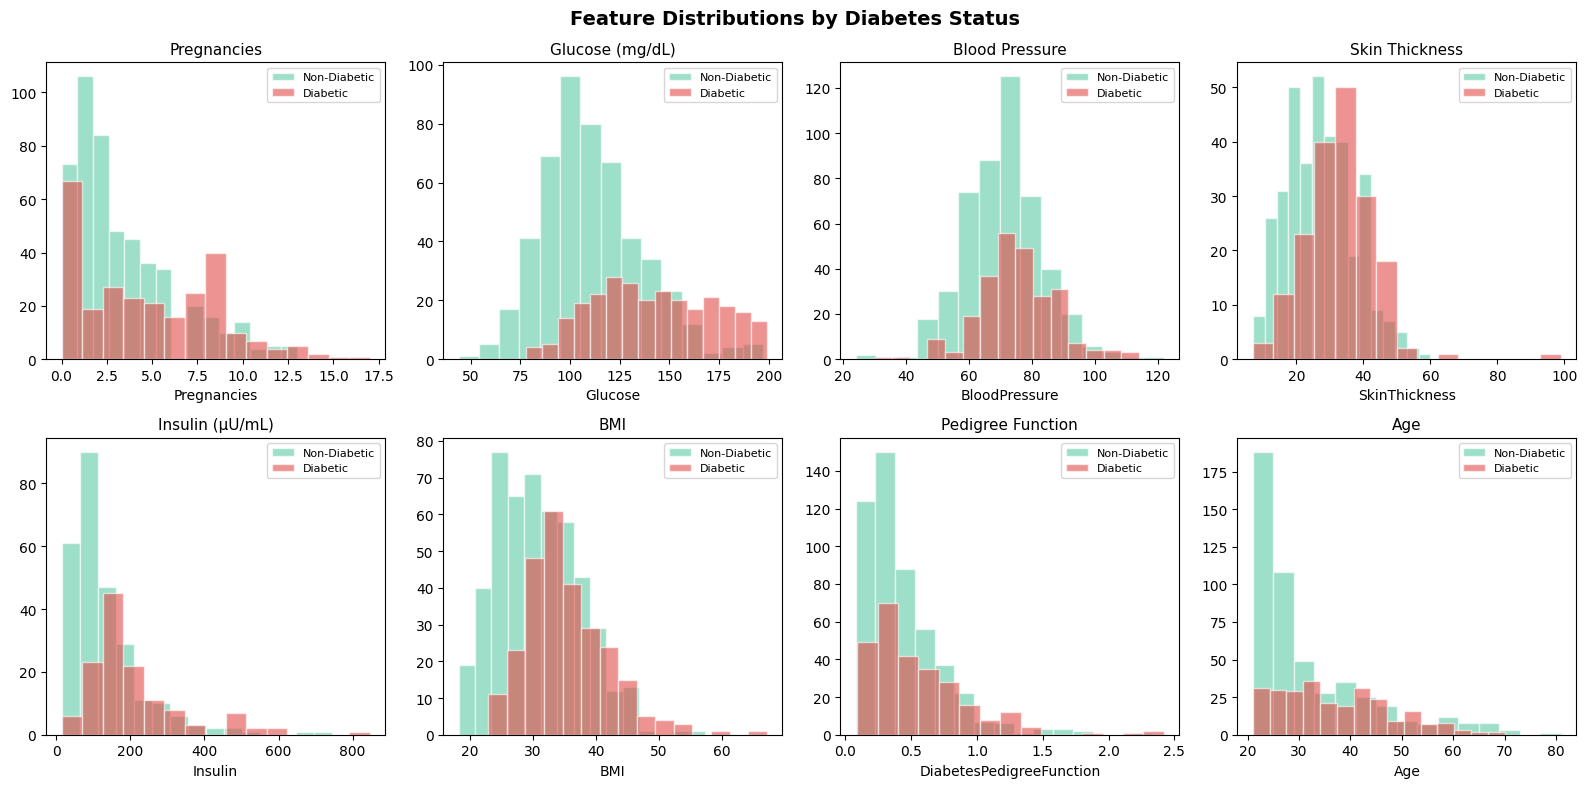

💡 Notice which features separate the two groups most clearly — SHAP will confirm this!


In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Feature Distributions by Diabetes Status', fontsize=14, fontweight='bold')

features_to_plot = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
labels = ['Pregnancies', 'Glucose (mg/dL)', 'Blood Pressure', 'Skin Thickness',
          'Insulin (μU/mL)', 'BMI', 'Pedigree Function', 'Age']

for ax, feat, lbl in zip(axes.flatten(), features_to_plot, labels):
    for target_val, color, name in [(0, '#5DCAA5', 'Non-Diabetic'),
                                     (1, '#E24B4A', 'Diabetic')]:
        subset = df[df['Outcome'] == target_val][feat].dropna()
        ax.hist(subset, bins=15, alpha=0.6, color=color, label=name, edgecolor='white')
    ax.set_title(lbl, fontsize=11)
    ax.set_xlabel(feat)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Notice which features separate the two groups most clearly — SHAP will confirm this!")

## Step 5 — Train / Test Split & Model Training
> **Student Task:** Modify `n_estimators` and `max_depth` and observe how accuracy changes.

In [5]:
feature_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

X = df[feature_names].values
y = df['Outcome'].values

# Split data before imputation to guarantee zero data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# -------------------------------------------------------------------------
# Leakage-Free Pipeline:
# SimpleImputer computes medians exclusively from X_train and applies them to X_test
# STUDENT TASK: Try changing n_estimators (50, 100, 200) and max_depth (None, 5, 10)
# -------------------------------------------------------------------------
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', RandomForestClassifier(
        n_estimators=100,   # <-- change me
        max_depth=None,     # <-- change me
        random_state=42
    ))
])

# Fit pipeline strictly on training data
pipeline.fit(X_train, y_train)

# Evaluate on test set
y_pred = pipeline.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")
print(f"
✅ Model Accuracy : {acc:.4f} ({acc*100:.1f}%)")
print("
Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Diabetic', 'Diabetic']))

# Extract fitted steps and imputed feature sets for downstream XAI explainers
imputer = pipeline.named_steps['imputer']
model = pipeline.named_steps['classifier']
X_train = imputer.transform(X_train)
X_test = imputer.transform(X_test)

Training samples : 614
Testing  samples : 154

✅ Model Accuracy : 0.7468 (74.7%)

Detailed Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.79      0.84      0.81       100
    Diabetic       0.66      0.57      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.71       154
weighted avg       0.74      0.75      0.74       154



## Step 6 — SHAP: Global Feature Importance (Summary Plot)

### Concept
SHAP values are based on **Shapley values** from cooperative game theory.  
Each feature gets a value = *how much it contributed to pushing the prediction away from the baseline*.  

- **Positive SHAP** → pushes prediction toward Diabetic (class 1)  
- **Negative SHAP** → pushes prediction toward Non-Diabetic (class 0)  

The **summary plot** shows global importance across all test patients.


Model and data already loaded.
Computing SHAP values...


  SHAP values ready.


SHAP values shape (class 1): (154, 8)
= (154 patients, 8 features)



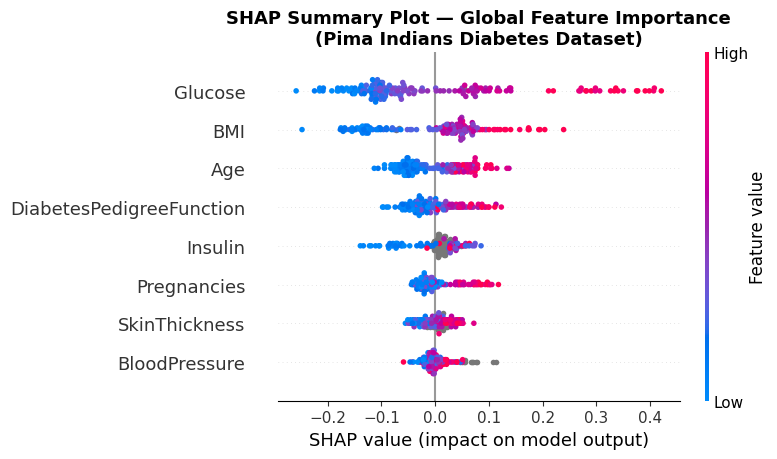

💡 X-axis = SHAP value. Color = feature value (red=high, blue=low).
💡 Features ranked by mean |SHAP| — most important at top.
💡 Glucose typically dominates — the key biomarker for diabetes!


In [6]:
ensure_ready('shap')

# Create TreeExplainer — optimised for tree-based models
if 'explainer' not in globals() or 'shap_values' not in globals():
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)   # shape: (samples, features, classes)

print(f"SHAP values shape (class 1): {shap_values[:, :, 1].shape}")
print(f"= ({len(X_test)} patients, {len(feature_names)} features)")
print()

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values[:, :, 1],   # SHAP values for Diabetic class
    X_test,
    feature_names=feature_names,
    plot_type='dot',
    show=False
)
plt.title('SHAP Summary Plot — Global Feature Importance\n(Pima Indians Diabetes Dataset)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 X-axis = SHAP value. Color = feature value (red=high, blue=low).")
print("💡 Features ranked by mean |SHAP| — most important at top.")
print("💡 Glucose typically dominates — the key biomarker for diabetes!")

## Step 7 — SHAP: Bar Plot (Mean Absolute Importance)
> Bar plot shows the average magnitude of each feature's contribution across all patients.

Model and data already loaded.
SHAP values already computed.


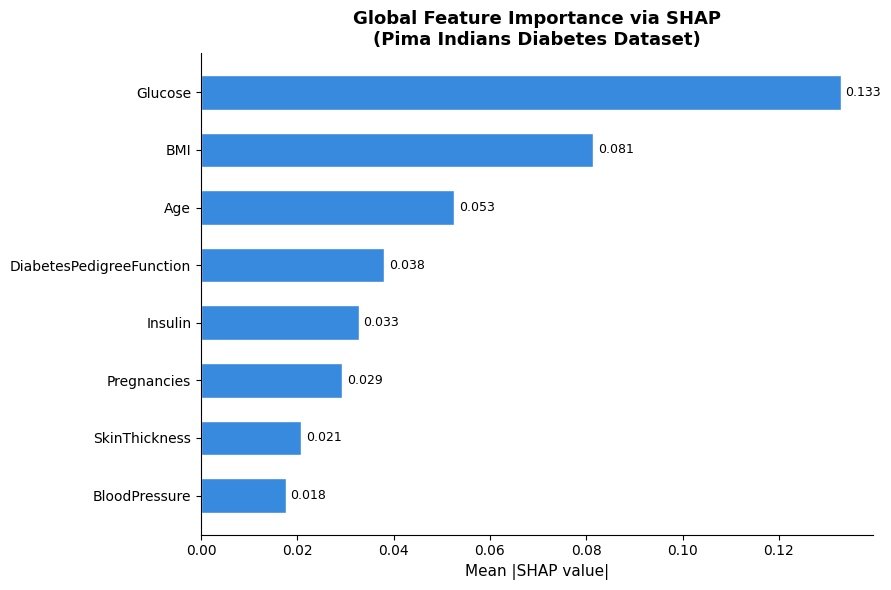

Top 3 most important features:
Feature  Mean |SHAP|
    Age     0.052502
    BMI     0.081493
Glucose     0.132807


In [7]:
ensure_ready('shap')

mean_shap = np.abs(shap_values[:, :, 1]).mean(axis=0)
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean |SHAP|': mean_shap
}).sort_values('Mean |SHAP|', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importance_df['Feature'], importance_df['Mean |SHAP|'],
               color='#378ADD', edgecolor='white', height=0.6)
ax.set_xlabel('Mean |SHAP value|', fontsize=11)
ax.set_title('Global Feature Importance via SHAP\n(Pima Indians Diabetes Dataset)',
             fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, val in zip(bars, importance_df['Mean |SHAP|']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 3 most important features:")
print(importance_df.tail(3)[['Feature','Mean |SHAP|']].to_string(index=False))

## Step 8 — SHAP: Local Explanation for a Single Patient

The **waterfall plot** shows exactly why the model predicted what it did for ONE patient.  
- Starts at the base value (average prediction across all patients)
- Each feature either adds to or subtracts from the final prediction


Model and data already loaded.
SHAP values already computed.
Patient #0
True label  : Non-Diabetic
Predicted   : Diabetic (prob=0.650)

Patient feature values:
  Pregnancies              : 7.0
  Glucose                  : 159.0
  BloodPressure            : 64.0
  SkinThickness            : nan
  Insulin                  : nan
  BMI                      : 27.4
  DiabetesPedigreeFunction : 0.3
  Age                      : 40.0


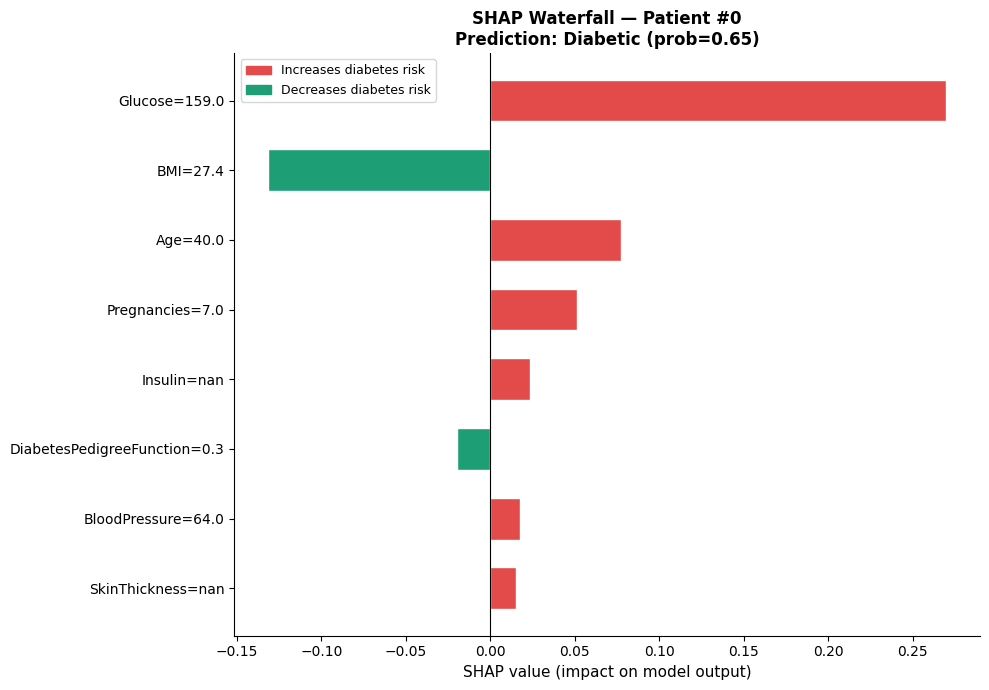

In [8]:
ensure_ready('shap')

# -------------------------------------------------------
# STUDENT TASK: Change patient_idx to any value 0 to len(X_test)-1
#               Observe how the explanation changes!
# -------------------------------------------------------
patient_idx = 0   # <-- change me

patient    = X_test[patient_idx]
true_label = y_test[patient_idx]
pred_prob  = model.predict_proba(patient.reshape(1, -1))[0]
pred_label = model.predict(patient.reshape(1, -1))[0]

print(f"Patient #{patient_idx}")
print(f"True label  : {'Diabetic' if true_label==1 else 'Non-Diabetic'}")
print(f"Predicted   : {'Diabetic' if pred_label==1 else 'Non-Diabetic'} (prob={pred_prob[1]:.3f})")
print()
print("Patient feature values:")
for name, val in zip(feature_names, patient):
    print(f"  {name:25s}: {val:.1f}")

# Waterfall chart for this patient
patient_shap = shap_values[patient_idx, :, 1]

shap_df = pd.DataFrame({
    'Feature': [f"{n}={v:.1f}" for n, v in zip(feature_names, patient)],
    'SHAP':    patient_shap
}).sort_values('SHAP', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#E24B4A' if v > 0 else '#1D9E75' for v in shap_df['SHAP']]
ax.barh(shap_df['Feature'], shap_df['SHAP'], color=colors, edgecolor='white', height=0.6)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('SHAP value (impact on model output)', fontsize=11)
ax.set_title(
    f'SHAP Waterfall — Patient #{patient_idx}\n'
    f'Prediction: {"Diabetic" if pred_label==1 else "Non-Diabetic"} (prob={pred_prob[1]:.2f})',
    fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
red_patch   = mpatches.Patch(color='#E24B4A', label='Increases diabetes risk')
green_patch = mpatches.Patch(color='#1D9E75', label='Decreases diabetes risk')
ax.legend(handles=[red_patch, green_patch], fontsize=9)
plt.tight_layout()
plt.savefig(f'shap_waterfall_patient{patient_idx}.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9 — SHAP: Force Plot (Interactive)

The **force plot** is SHAP's iconic visualisation.  
- Red features **push** the prediction higher (toward diabetic)  
- Blue features **push** the prediction lower (away from diabetic)  
- The base value is the average model output


In [9]:
ensure_ready('shap')

patient_idx = 0 if 'patient_idx' not in globals() else patient_idx

force_plot = shap.force_plot(
    base_value=explainer.expected_value[1],
    shap_values=shap_values[patient_idx, :, 1],
    features=X_test[patient_idx],
    feature_names=feature_names
)
shap.save_html('force_plot.html', force_plot)
force_plot

Model and data already loaded.
SHAP values already computed.


## Step 10 — SHAP: Dependence Plot

A **dependence plot** shows how a single feature's value affects its SHAP contribution.  
The color shows interaction with another feature (auto-selected by SHAP).


Model and data already loaded.
SHAP values already computed.


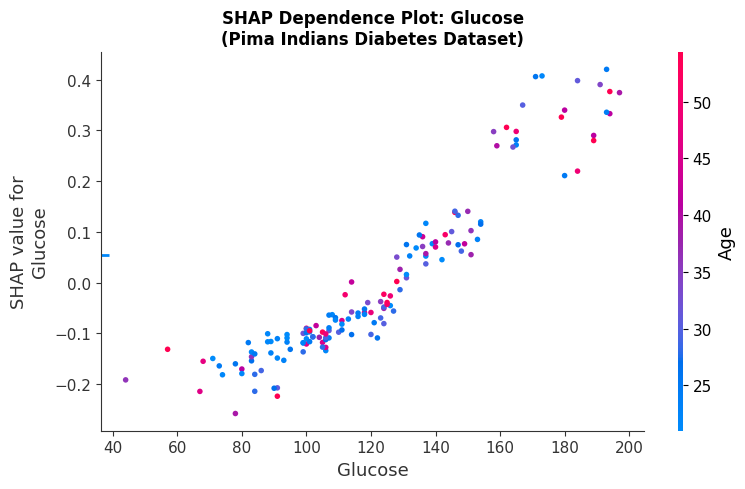

💡 X-axis = feature value. Y-axis = SHAP value. Color = interacting feature.
💡 Higher glucose → consistently positive SHAP → stronger diabetes prediction!


In [10]:
ensure_ready('shap')

# -------------------------------------------------------
# STUDENT TASK: Change the feature name below.
# Try: 'Glucose', 'BMI', 'Age', 'Insulin', 'Pregnancies'
# -------------------------------------------------------
feature_to_plot = 'Glucose'   # <-- change me

fig, ax = plt.subplots(figsize=(8, 5))
shap.dependence_plot(
    feature_to_plot,
    shap_values[:, :, 1],    # SHAP values for Diabetic class
    X_test,
    feature_names=feature_names,
    ax=ax,
    show=False
)
ax.set_title(f'SHAP Dependence Plot: {feature_to_plot}\n(Pima Indians Diabetes Dataset)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'shap_dependence_{feature_to_plot}.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 X-axis = feature value. Y-axis = SHAP value. Color = interacting feature.")
print("💡 Higher glucose → consistently positive SHAP → stronger diabetes prediction!")

## Step 11 — LIME: Local Explanation for a Single Patient

### Concept
LIME fits a **local linear model** in the neighbourhood of the patient being explained.  

Algorithm:
1. Perturb the patient's features randomly (generate synthetic neighbours)
2. Get the black-box model's predictions for all neighbours
3. Weight neighbours by their proximity to the original patient
4. Fit a simple **linear regression** on the weighted neighbours
5. The linear model's coefficients are the LIME explanation


In [11]:
ensure_ready('lime')

# Create the LIME explainer — must know training data distribution
if 'lime_explainer' not in globals():
    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train,
        feature_names=feature_names,
        class_names=['Non-Diabetic', 'Diabetic'],
        mode='classification',
        random_state=42
    )

print("✅ LIME explainer created!")
print(f"Training distribution shape: {X_train.shape}")
print("The explainer will sample perturbations from this training distribution.")

Model and data already loaded.
SHAP values already computed.
Setting up LIME explainer...
  LIME explainer ready.
✅ LIME explainer created!
Training distribution shape: (614, 8)
The explainer will sample perturbations from this training distribution.


In [12]:
ensure_ready('lime')

# -------------------------------------------------------
# STUDENT TASK: Change patient_idx and num_features
#               Observe how the explanation changes!
# -------------------------------------------------------
patient_idx  = 0    # <-- change me (0 to len(X_test)-1)
num_features = 8    # <-- change me (try 5 or 8)

lime_exp = lime_explainer.explain_instance(
    data_row=X_test[patient_idx],
    predict_fn=model.predict_proba,
    num_features=num_features,
    num_samples=1000
)

print(f"Patient #{patient_idx} — LIME Explanation")
print(f"Predicted probability of Diabetes: "
      f"{model.predict_proba(X_test[patient_idx].reshape(1,-1))[0][1]:.3f}")
print()
print("Feature conditions and their weights:")
for feat, weight in lime_exp.as_list():
    direction = "↑ increases risk" if weight > 0 else "↓ decreases risk"
    print(f"  {feat:45s}: {weight:+.4f}  ({direction})")

Model and data already loaded.
SHAP values already computed.
LIME explainer already set up.
Patient #0 — LIME Explanation
Predicted probability of Diabetes: 0.650

Feature conditions and their weights:
  29.00 < Age <= 41.00                         : +0.1244  (↑ increases risk)
  Pregnancies > 6.00                           : +0.1036  (↑ increases risk)
  0.24 < DiabetesPedigreeFunction <= 0.38      : +0.0176  (↑ increases risk)
  Insulin <= nan                               : +0.0000  (↓ decreases risk)
  BMI <= nan                                   : +0.0000  (↓ decreases risk)
  Glucose <= nan                               : +0.0000  (↓ decreases risk)
  BloodPressure <= nan                         : +0.0000  (↓ decreases risk)
  SkinThickness <= nan                         : +0.0000  (↓ decreases risk)


Model and data already loaded.
SHAP values already computed.
LIME explainer already set up.


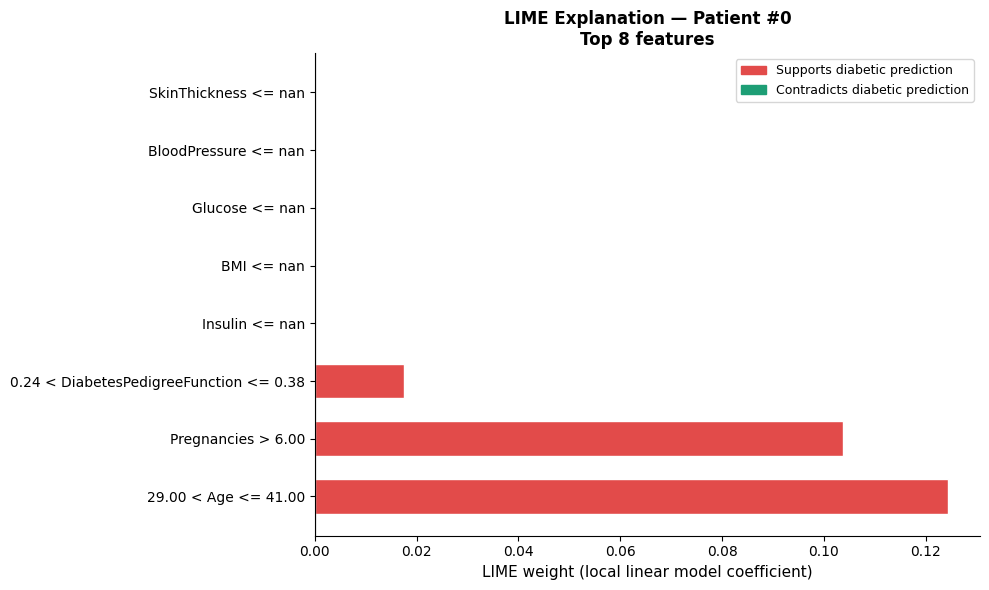

In [13]:
ensure_ready('lime')

# LIME bar chart visualisation
lime_list     = lime_exp.as_list()
features_lime = [x[0] for x in lime_list]
weights_lime  = [x[1] for x in lime_list]
colors_lime   = ['#E24B4A' if w > 0 else '#1D9E75' for w in weights_lime]

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = range(len(features_lime))
ax.barh(y_pos, weights_lime, color=colors_lime, edgecolor='white', height=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(features_lime, fontsize=10)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('LIME weight (local linear model coefficient)', fontsize=11)
ax.set_title(f'LIME Explanation — Patient #{patient_idx}\nTop {num_features} features',
             fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
red_patch   = mpatches.Patch(color='#E24B4A', label='Supports diabetic prediction')
green_patch = mpatches.Patch(color='#1D9E75', label='Contradicts diabetic prediction')
ax.legend(handles=[red_patch, green_patch], fontsize=9)
plt.tight_layout()
plt.savefig(f'lime_patient{patient_idx}.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
ensure_ready('lime')

# Display LIME explanation as a table (notebook-safe alternative)
lime_as_list = lime_exp.as_list()
lime_table = pd.DataFrame(lime_as_list, columns=['Feature Condition', 'Weight'])
lime_table['Direction'] = lime_table['Weight'].apply(lambda w: '🔴 Risk ↑' if w > 0 else '🟢 Risk ↓')
lime_table['Weight'] = lime_table['Weight'].round(4)
print("LIME Explanation Table (Patient #{})".format(patient_idx))
print("=" * 65)
print(lime_table.to_string(index=False))

Model and data already loaded.
SHAP values already computed.
LIME explainer already set up.
LIME Explanation Table (Patient #0)
                      Feature Condition  Weight Direction
                   29.00 < Age <= 41.00  0.1244  🔴 Risk ↑
                     Pregnancies > 6.00  0.1036  🔴 Risk ↑
0.24 < DiabetesPedigreeFunction <= 0.38  0.0176  🔴 Risk ↑
                         Insulin <= nan  0.0000  🟢 Risk ↓
                             BMI <= nan  0.0000  🟢 Risk ↓
                         Glucose <= nan  0.0000  🟢 Risk ↓
                   BloodPressure <= nan  0.0000  🟢 Risk ↓
                   SkinThickness <= nan  0.0000  🟢 Risk ↓


## Step 12 — SHAP vs LIME: Side-by-Side Comparison

> **Key Question:** Do SHAP and LIME agree on which features matter most for this patient?


Model and data already loaded.
SHAP values already computed.
LIME explainer already set up.


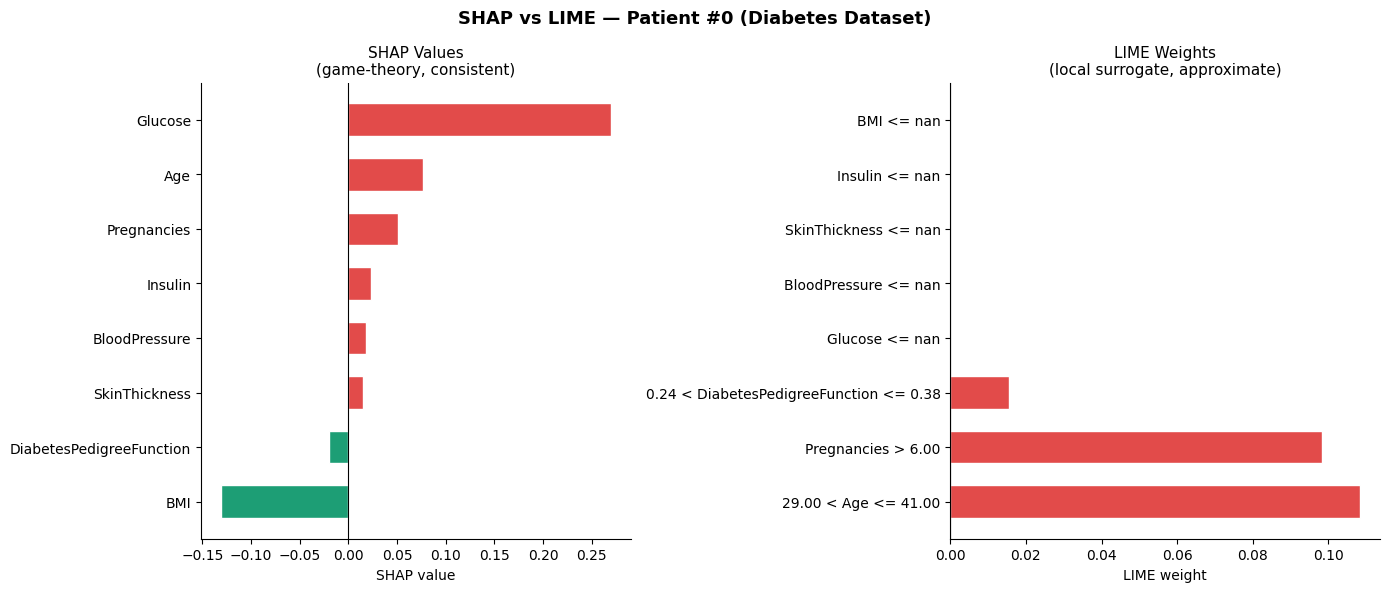

Reflection questions:
  1. Do both methods agree on the TOP feature? (Likely Glucose)
  2. Does LIME show raw values or rule conditions?
  3. Which is easier to explain to a physician — SHAP or LIME?


In [15]:
ensure_ready('all')

# -------------------------------------------------------
# STUDENT TASK: Try different patient indices.
#               Do SHAP and LIME always agree?
# -------------------------------------------------------
patient_idx = 0   # <-- change me

# SHAP values for this patient (class 1 — Diabetic)
shap_patient    = shap_values[patient_idx, :, 1]
shap_df_compare = pd.DataFrame({'Feature': feature_names, 'SHAP': shap_patient})
shap_df_compare['abs_SHAP'] = shap_df_compare['SHAP'].abs()
shap_df_compare = shap_df_compare.sort_values('abs_SHAP', ascending=False).head(8)

# LIME values for same patient
lime_exp2  = lime_explainer.explain_instance(
    X_test[patient_idx], model.predict_proba, num_features=8, num_samples=1000)

# Plot side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'SHAP vs LIME — Patient #{patient_idx} (Diabetes Dataset)',
             fontsize=13, fontweight='bold')

shap_sorted = shap_df_compare.sort_values('SHAP')
colors_s = ['#E24B4A' if v > 0 else '#1D9E75' for v in shap_sorted['SHAP']]
ax1.barh(shap_sorted['Feature'], shap_sorted['SHAP'],
         color=colors_s, edgecolor='white', height=0.6)
ax1.axvline(0, color='black', linewidth=0.8)
ax1.set_title('SHAP Values\n(game-theory, consistent)', fontsize=11)
ax1.set_xlabel('SHAP value')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

lime_items = lime_exp2.as_list()
lime_feats = [x[0] for x in lime_items]
lime_vals  = [x[1] for x in lime_items]
colors_l   = ['#E24B4A' if v > 0 else '#1D9E75' for v in lime_vals]
ax2.barh(lime_feats, lime_vals, color=colors_l, edgecolor='white', height=0.6)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title('LIME Weights\n(local surrogate, approximate)', fontsize=11)
ax2.set_xlabel('LIME weight')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'shap_vs_lime_patient{patient_idx}.png', dpi=150, bbox_inches='tight')
plt.show()

print("Reflection questions:")
print("  1. Do both methods agree on the TOP feature? (Likely Glucose)")
print("  2. Does LIME show raw values or rule conditions?")
print("  3. Which is easier to explain to a physician — SHAP or LIME?")

## Step 13 — Challenge Exercise

**Task:** Find the patient in the test set whose prediction is hardest for the model  
(i.e., the patient closest to 50% probability — most uncertain).  
Then explain that patient using both SHAP and LIME and answer:
- Why is the model uncertain for this patient?
- Which features are pulling in opposite directions?


In [16]:
ensure_ready('all')

# Step 1: Find the most uncertain patient
probs       = model.predict_proba(X_test)[:, 1]
uncertainty = np.abs(probs - 0.5)
hardest_idx = np.argmin(uncertainty)

print(f"Most uncertain patient index  : {hardest_idx}")
print(f"Predicted probability of diabetes: {probs[hardest_idx]:.4f}")
print(f"True label: {'Diabetic' if y_test[hardest_idx]==1 else 'Non-Diabetic'}")
print()
print("Patient feature values:")
for name, val in zip(feature_names, X_test[hardest_idx]):
    print(f"  {name:25s}: {val:.1f}")

# -------------------------------------------------------
# STUDENT TASK: Now explain this patient using SHAP and LIME.
# Copy the code from Steps 8 and 11, replace patient_idx with hardest_idx.
# Write your analysis as a markdown cell below.
# -------------------------------------------------------

# YOUR CODE HERE
# shap explanation for hardest_idx ...
# lime explanation for hardest_idx ...

Model and data already loaded.
SHAP values already computed.
LIME explainer already set up.
Most uncertain patient index  : 6
Predicted probability of diabetes: 0.5000
True label: Diabetic

Patient feature values:
  Pregnancies              : 8.0
  Glucose                  : 105.0
  BloodPressure            : 100.0
  SkinThickness            : 36.0
  Insulin                  : nan
  BMI                      : 43.3
  DiabetesPedigreeFunction : 0.2
  Age                      : 45.0


## Step 14 — Summary Comparison Table

| Attribute | SHAP | LIME |
|-----------|------|------|
| **Theoretical basis** | Shapley values (game theory) | Local linear surrogate |
| **Scope** | Global + Local | Local only |
| **Consistency** | Deterministic | Stochastic (varies per run) |
| **Speed (tree models)** | Very fast (TreeSHAP) | Moderate |
| **Output** | Raw feature contributions | Rule-based conditions |
| **Model agnostic** | No (TreeSHAP) / Yes (KernelSHAP) | Yes |
| **Best for** | Auditing, fairness, global analysis | Quick local explanations |
| **Interpretability** | Slightly technical | Very intuitive (if-then rules) |

### When to use what?
- Use **SHAP** when you need consistent, theoretically grounded explanations — model auditing, regulatory compliance, research papers.
- Use **LIME** when you need a quick, easily communicable local explanation — explaining to a clinician or non-technical stakeholder.
- In practice: **use both** and check if they agree. Disagreement signals model instability.

### Key Insights from the Pima Indians Diabetes Dataset
- **Glucose** dominates both SHAP and LIME explanations — the most clinically validated predictor of diabetes.
- **BMI** and **Age** are consistently high-importance features across both methods.
- **DiabetesPedigreeFunction** reveals how genetic risk propagates — visible in the SHAP dependence plot.
- Patients near the 50% decision boundary (Step 13) often have contradictory signals: high glucose but low BMI, or young age with high pedigree score.

---
## Lab Complete! ✅

**Submission checklist:**
- [ ] All cells executed in order (no errors)
- [ ] Changed `patient_idx` in at least 3 cells and observed differences
- [ ] Changed `feature_to_plot` in Step 10 and observed the dependence plot change
- [ ] Completed Step 13 challenge with analysis
- [ ] Downloaded plots: `shap_summary.png`, `shap_bar.png`, `shap_vs_lime_patient0.png`
- [ ] Written a 5-line reflection: *"What did you observe when comparing SHAP and LIME on the Diabetes dataset?"*
